Importing necessary libraries

In [32]:
# Imports & Data Loading

# ok so we need all these libraries to make everything work
# pandas and numpy are basically just for handling the data
# matplotlib is for making the graphs look nice at the end
# sklearn has all the actual ML stuff we need like the models and tuning tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns  # for cleaner, more detailed plots alongside matplotlib

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")  # just hiding annoying warnings that dont really matter

Loading the dataset

In [33]:
# Load the dataset
df = pd.read_csv("uae_real_estate_2024.csv")

Analyzing the dataset visually

In [34]:
# Basic overview
print("Shape:", df.shape)

Shape: (5058, 12)


In [35]:
df.describe(include='all')

,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
count,5058,5058,4938,4935,5058,5058,5.058000e+03,5058,5058,5058,5056,5057
unique,5002,1886,9,9,4927,1,NaN,2,1,2516,3,4940
top,Waterfront | Emaar | Luxury | PP 80/20,"Hayyan, Sharjah",2,1,2024-07-29T14:12:37Z,Residential for Sale,NaN,True,sell,3014 sqft,NO,*Luxury residential complex with a 5% down pay...
freq,3,40,1209,1265,7,5058,NaN,3271,5058,46,3630,8
mean,NaN,NaN,NaN,NaN,NaN,NaN,5.050924e+06,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.000928e+07,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+05,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+06,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.350000e+06,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,4.499375e+06,NaN,NaN,NaN,NaN,NaN


In [36]:
print("\nColumn names:", df.columns.tolist())


Column names: ['title', 'displayAddress', 'bathrooms', 'bedrooms', 'addedOn', 'type', 'price', 'verified', 'priceDuration', 'sizeMin', 'furnishing', 'description']


In [37]:
print("\nData types:\n", df.dtypes)


Data types:
 title               str
displayAddress      str
bathrooms           str
bedrooms            str
addedOn             str
type                str
price             int64
verified           bool
priceDuration       str
sizeMin             str
furnishing          str
description         str
dtype: object


In [38]:
print("\nFirst 3 rows:")
df.head(3)


First 3 rows:


,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
0,Great ROI I High Floor I Creek View,"Binghatti Canal, Business Bay, Dubai",3,2,2024-08-14T12:02:53Z,Residential for Sale,2500000,True,sell,1323 sqft,NO,MNA Properties is delighted to offer this apar...
1,Full Sea View | Beach Life | Brand New Residence,"La Vie, Jumeirah Beach Residence, Dubai",3,2,2024-08-13T05:45:16Z,Residential for Sale,7200000,True,sell,1410 sqft,YES,"Apartment for sale in La Vie, Jumeirah Beach R..."
2,Green Belt | Corner Unit | Spacious Plot,"La Rosa 6, Villanova, Dubai Land, Dubai",3,4,2024-08-14T06:24:28Z,Residential for Sale,3600000,True,sell,2324 sqft,NO,Treo Homes is very pleased to be bringing to t...


In [39]:
print("Shape: ", df.shape)
print("\nUnique values per column:\n")
print(df.nunique())

Shape:  (5058, 12)

Unique values per column:

title             5002
displayAddress    1886
bathrooms            9
bedrooms             9
addedOn           4927
type                 1
price             1542
verified             2
priceDuration        1
sizeMin           2516
furnishing           3
description       4940
dtype: int64


In [40]:
# Missing Values & Duplicates Check

# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Check for duplicate rows
print(f"\n==== Duplicate Rows ====")
print(f"Number of duplicates: {df.duplicated().sum()}")

=== Missing Values ===
title               0
displayAddress      0
bathrooms         120
bedrooms          123
addedOn             0
type                0
price               0
verified            0
priceDuration       0
sizeMin             0
furnishing          2
description         1
dtype: int64

Total missing: 246

==== Duplicate Rows ====
Number of duplicates: 0


Preprocesing - Step 1 

In [41]:
# Drop Useless Columns

# Drop columns with only 1 unique value - no predictive power
# 'type' is always "Residential for Sale", 'priceDuration' is always "sell"
df = df.drop(columns=['type', 'priceDuration'])
print("Dropped 'type' and 'priceDuration' (constant columns)")

# Drop 'title' and 'description' - free text, not useful for prediction in our case, and would require complex NLP to extract value
df = df.drop(columns=['title', 'description'])
print("Dropped 'title' and 'description' (unstructured text)")

Dropped 'type' and 'priceDuration' (constant columns)
Dropped 'title' and 'description' (unstructured text)


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   displayAddress  5058 non-null   str  
 1   bathrooms       4938 non-null   str  
 2   bedrooms        4935 non-null   str  
 3   addedOn         5058 non-null   str  
 4   price           5058 non-null   int64
 5   verified        5058 non-null   bool 
 6   sizeMin         5058 non-null   str  
 7   furnishing      5056 non-null   str  
dtypes: bool(1), int64(1), str(6)
memory usage: 281.7 KB


In [43]:
# Fix Data Types

# Fix 'sizeMin': remove " sqft" and convert to numeric
df['sizeMin'] = df['sizeMin'].str.replace(' sqft', '', regex=False)
df['sizeMin'] = pd.to_numeric(df['sizeMin'], errors='coerce')
print("\n'sizeMin' converted to numeric")

# Fix 'addedOn': parse datetime and extract month (seasonality signal)
df['addedOn'] = pd.to_datetime(df['addedOn'], utc=True)
df['month_listed'] = df['addedOn'].dt.month
df = df.drop(columns=['addedOn'])
print("'addedOn' parsed - extracted 'month_listed', original column dropped")

# Fix 'bathrooms' and 'bedrooms': they loaded as object, convert to numeric
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
print("'bathrooms' and 'bedrooms' converted to numeric")

print("\n=== Updated dtypes ===")
print(df.dtypes)
print("\nShape:", df.shape)


'sizeMin' converted to numeric
'addedOn' parsed - extracted 'month_listed', original column dropped
'bathrooms' and 'bedrooms' converted to numeric

=== Updated dtypes ===
displayAddress        str
bathrooms         float64
bedrooms          float64
price               int64
verified             bool
sizeMin             int64
furnishing            str
month_listed        int32
dtype: object

Shape: (5058, 8)



Shape before outlier handling: (5058, 8)


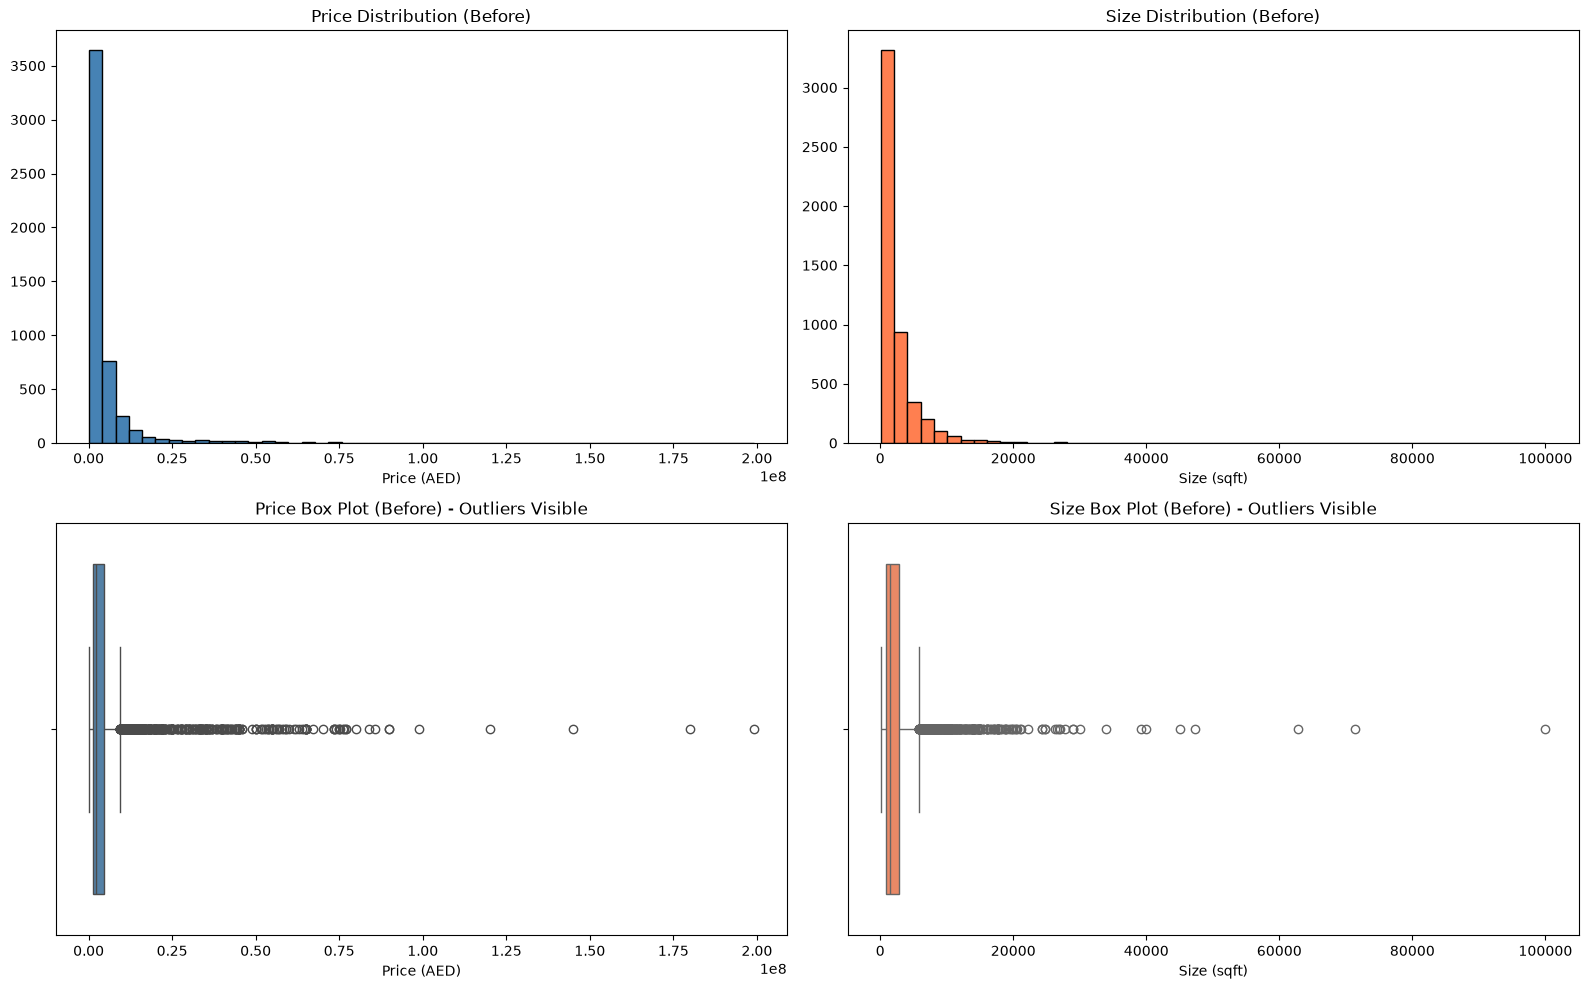

'price': removed 51 top outliers (above 99th percentile = 54,351,500)
'sizeMin': removed 51 top outliers (above 99th percentile = 14,754)

Shape after outlier handling: (4956, 8)


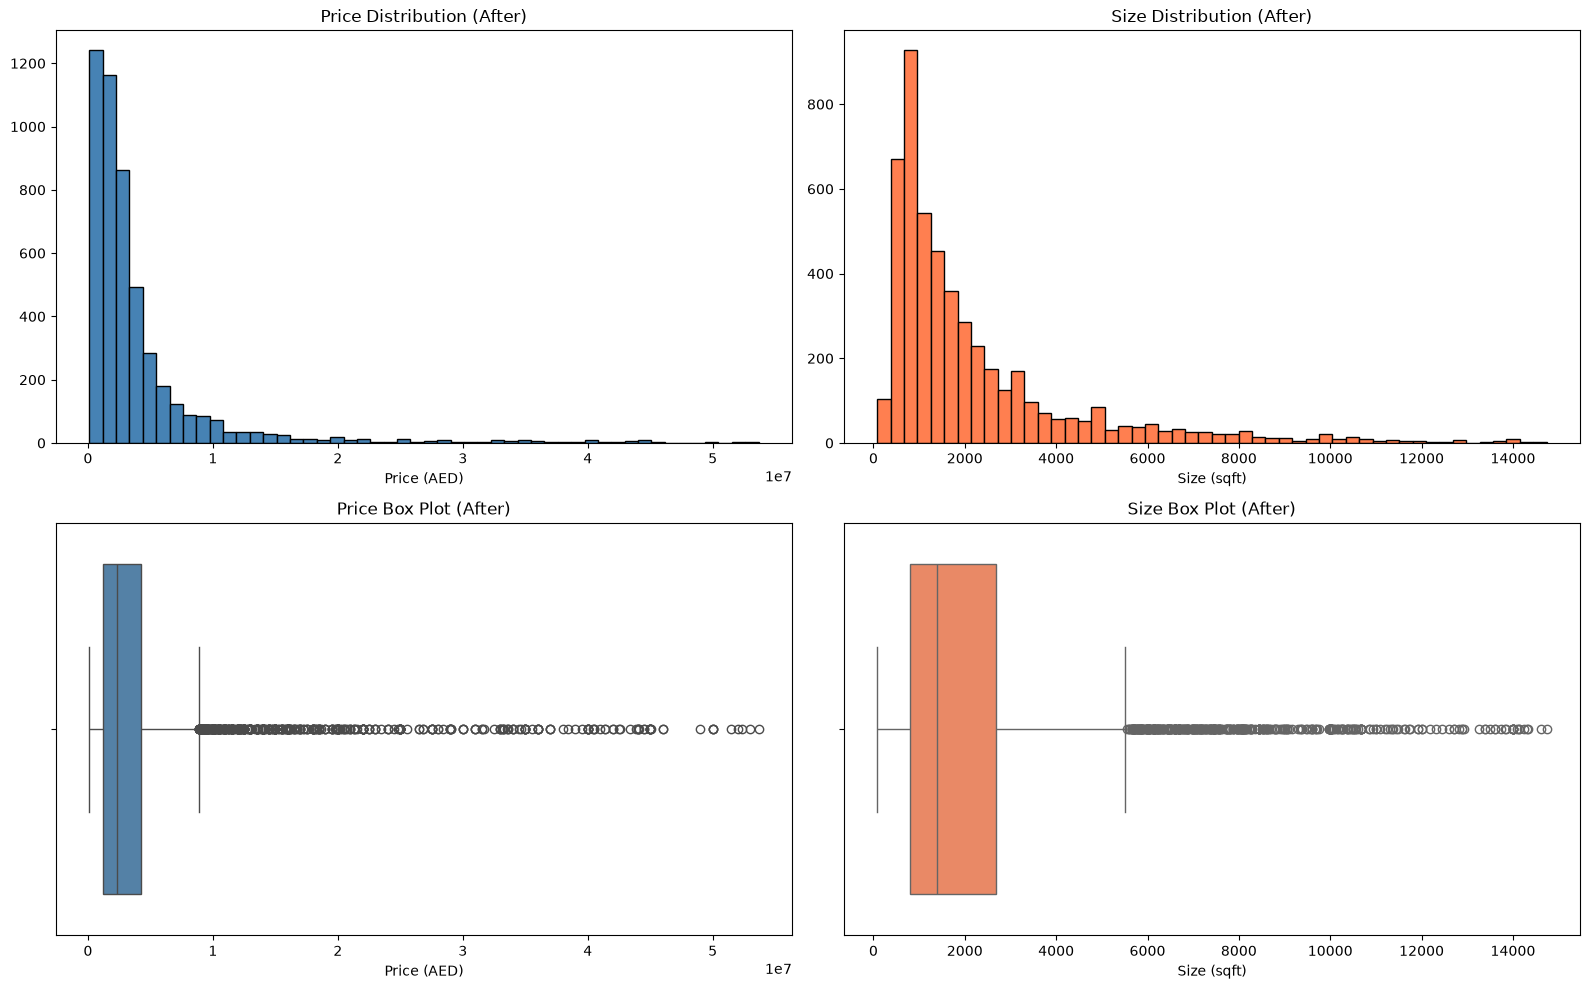

In [44]:
# Outlier Detection & Removal - Histograms & Boxplots (Before & After)

print(f"\nShape before outlier handling: {df.shape}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histograms BEFORE outlier handling
axes[0, 0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution (Before)')
axes[0, 0].set_xlabel('Price (AED)')

axes[0, 1].hist(df['sizeMin'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Size Distribution (Before)')
axes[0, 1].set_xlabel('Size (sqft)')

# Box Plots BEFORE outlier handling
sns.boxplot(x=df['price'], ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Price Box Plot (Before) - Outliers Visible')
axes[1, 0].set_xlabel('Price (AED)')

sns.boxplot(x=df['sizeMin'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Size Box Plot (Before) - Outliers Visible')
axes[1, 1].set_xlabel('Size (sqft)')

plt.tight_layout()
plt.show()

# Outlier handling function

def handle_top_outliers(dataframe, column):
    #Handles only the top extreme outliers.

    percentile=99

    upper_limit = dataframe[column].quantile(percentile / 100.0)
    before = len(dataframe)
    
    dataframe = dataframe[dataframe[column] <= upper_limit].copy()
    removed = before - len(dataframe)
    print(f"'{column}': removed {removed} top outliers (above {percentile}th percentile = {upper_limit:,.0f})")
    
    return dataframe

# Applying top outlier handling
df = handle_top_outliers(df, 'price')
df = handle_top_outliers(df, 'sizeMin')

print(f"\nShape after outlier handling: {df.shape}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histograms AFTER outlier handling
axes[0, 0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution (After)')
axes[0, 0].set_xlabel('Price (AED)')

axes[0, 1].hist(df['sizeMin'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Size Distribution (After)')
axes[0, 1].set_xlabel('Size (sqft)')

# Box Plots AFTER outlier handling
sns.boxplot(x=df['price'], ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Price Box Plot (After)')
axes[1, 0].set_xlabel('Price (AED)')

sns.boxplot(x=df['sizeMin'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Size Box Plot (After)')
axes[1, 1].set_xlabel('Size (sqft)')

plt.tight_layout()
plt.show()

In [45]:
# 'furnishing': drop rows with missing values (since furnishing has a significant impact on price and there are only two missing values, dropping them is a better approach than imputing, which could introduce bias).
mask = df.query('furnishing.isnull()')
df.drop(index = mask.index, inplace=True)

In [46]:
df.shape

(4954, 8)

In [47]:
# Encode Categorical Variables

# 'verified': convert bool to int (True=1, False=0)
df['verified'] = df['verified'].map({True: 1, False: 0})
print("'verified' encoded: True -> 1, False -> 0")

df

'verified' encoded: True -> 1, False -> 0


,displayAddress,bathrooms,bedrooms,price,verified,sizeMin,furnishing,month_listed
0,"Binghatti Canal, Business Bay, Dubai",3.0,2.0,2500000,1,1323,NO,8
1,"La Vie, Jumeirah Beach Residence, Dubai",3.0,2.0,7200000,1,1410,YES,8
2,"La Rosa 6, Villanova, Dubai Land, Dubai",3.0,4.0,3600000,1,2324,NO,8
3,"Springs 15, The Springs, Dubai",3.0,2.0,2999999,1,1647,NO,8
4,"Noor Townhouses, Town Square, Dubai",3.0,3.0,2449999,1,2105,NO,8
...,...,...,...,...,...,...,...,...
5053,"Sobha Creek Vistas Grande, Sobha Hartland, Moh...",3.0,2.0,2345000,1,1268,PARTLY,7
5054,"Al Marjan Island, Ras Al Khaimah",2.0,1.0,3007888,0,854,NO,8
5055,"Oia Residence, Motor City, Dubai",5.0,4.0,4000000,1,3813,NO,4
5056,"The Grand, Dubai Creek Harbour (The Lagoons), ...",2.0,2.0,3800000,1,1300,NO,7


In [48]:
# 'furnishing': one-hot encode (NO / YES / PARTLY)
# drop_first=False so all 3 categories are visible and explainable

df = pd.get_dummies(df, columns=['furnishing'], drop_first=False, sparse=False, prefix='furnished', dtype=int)
df.info()
df

<class 'pandas.DataFrame'>
Index: 4954 entries, 0 to 5057
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   displayAddress    4954 non-null   str    
 1   bathrooms         4774 non-null   float64
 2   bedrooms          4310 non-null   float64
 3   price             4954 non-null   int64  
 4   verified          4954 non-null   int64  
 5   sizeMin           4954 non-null   int64  
 6   month_listed      4954 non-null   int32  
 7   furnished_NO      4954 non-null   int64  
 8   furnished_PARTLY  4954 non-null   int64  
 9   furnished_YES     4954 non-null   int64  
dtypes: float64(2), int32(1), int64(6), str(1)
memory usage: 406.4 KB


,displayAddress,bathrooms,bedrooms,price,verified,sizeMin,month_listed,furnished_NO,furnished_PARTLY,furnished_YES
0,"Binghatti Canal, Business Bay, Dubai",3.0,2.0,2500000,1,1323,8,1,0,0
1,"La Vie, Jumeirah Beach Residence, Dubai",3.0,2.0,7200000,1,1410,8,0,0,1
2,"La Rosa 6, Villanova, Dubai Land, Dubai",3.0,4.0,3600000,1,2324,8,1,0,0
3,"Springs 15, The Springs, Dubai",3.0,2.0,2999999,1,1647,8,1,0,0
4,"Noor Townhouses, Town Square, Dubai",3.0,3.0,2449999,1,2105,8,1,0,0
...,...,...,...,...,...,...,...,...,...,...
5053,"Sobha Creek Vistas Grande, Sobha Hartland, Moh...",3.0,2.0,2345000,1,1268,7,0,1,0
5054,"Al Marjan Island, Ras Al Khaimah",2.0,1.0,3007888,0,854,8,1,0,0
5055,"Oia Residence, Motor City, Dubai",5.0,4.0,4000000,1,3813,4,1,0,0
5056,"The Grand, Dubai Creek Harbour (The Lagoons), ...",2.0,2.0,3800000,1,1300,7,1,0,0


Splitting into training and testing datasets

In [49]:
target_column = 'price'

X = df.drop(columns=[target_column])
y = df[target_column]

y_bins = pd.qcut(y, q=10, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y_bins)

Preprocessing - part 2

In [ ]:
# Impute Missing Values

imputer = SimpleImputer(strategy='median')

# 'bathrooms' and 'bedrooms': impute with median (robust to outliers)
# We fit the imputer on the training data to avoid data leakage, then transform both train and test sets. This ensures that the imputation is based only on the training data, which is crucial for maintaining the integrity of our model evaluation.
imputer.fit(X_train[['bathrooms']])

X_train['bathrooms'] = imputer.transform(X_train[['bathrooms']])
X_test['bathrooms'] = imputer.transform(X_test[['bathrooms']])


imputer.fit(X_train[['bedrooms']])

X_train['bedrooms'] = imputer.transform(X_train[['bedrooms']])
X_test['bedrooms'] = imputer.transform(X_test[['bedrooms']])

print(f"'bathrooms' median imputed: {X_train['bathrooms'].median()}")
print(f"'bedrooms' median imputed:  {X_train['bedrooms'].median()}")

# Verify no missing values remain
print("\n=== Missing Values After Imputation ===")
print(X_train.isnull().sum() + y_train.isnull().sum() + X_test.isnull().sum() + y_test.isnull().sum())

'bathrooms' median imputed: 3.0
'bedrooms' median imputed:  2.0

=== Missing Values After Imputation ===
displayAddress      0
bathrooms           0
bedrooms            0
verified            0
sizeMin             0
month_listed        0
furnished_NO        0
furnished_PARTLY    0
furnished_YES       0
dtype: int64


In [51]:
# 'displayAddress': extract the city/area (last part after last comma)
# e.g. "Binghatti Canal, Business Bay, Dubai" → "Dubai"

# Apply extraction to both train and test
X_train['city'] = X_train['displayAddress'].str.split(',', n=1).str[1].str.strip()
X_test['city']  = X_test['displayAddress'].str.split(',', n=1).str[1].str.strip()

print(f"\nUnique cities extracted: {X_train['city'].nunique()}")
print(X_train['city'].value_counts().head(10))


target_encoder = TargetEncoder(target_type='continuous', random_state=42)

# Fit on train only - we use y_train (the true prices) to calculate meaningful encodings
X_train['city_encoded'] = target_encoder.fit_transform(X=X_train[['city']], y=y_train)

# Transform test using the fitted encoder
X_test['city_encoded'] = target_encoder.transform(X_test[['city']])

# Drop original columns from both train and test
X_train = X_train.drop(columns=['displayAddress', 'city'])
X_test  = X_test.drop(columns=['displayAddress', 'city'])

print("\n'displayAddress' -> target-encoded as 'city_encoded' (fit only on train)")
print("Original columns dropped from both X_train and X_test")

print("\n=== Final Columns ===")
print("X_train columns:", X_train.columns.tolist())
print("X_test columns: ", X_test.columns.tolist())
print("\nTrain shape:", X_train.shape)
print("Test shape: ", X_test.shape)

# y_train and y_test remain unchanged - they are the target variables (prices)
print("\ny_train shape:", y_train.shape, "| y_test shape:", y_test.shape)


Unique cities extracted: 495
city
Jumeirah Village Circle, Dubai                     147
Dubai Marina, Dubai                                100
Business Bay, Dubai                                 84
Al Furjan, Dubai                                    76
Sobha Hartland, Mohammed Bin Rashid City, Dubai     76
Arjan, Dubai                                        70
EMAAR Beachfront, Dubai Harbour, Dubai              66
Damac Lagoons, Dubai                                61
Meydan One, Meydan, Dubai                           56
The Valley, Dubai                                   54
Name: count, dtype: int64

'displayAddress' -> target-encoded as 'city_encoded' (fit only on train)
Original columns dropped from both X_train and X_test

=== Final Columns ===
X_train columns: ['bathrooms', 'bedrooms', 'verified', 'sizeMin', 'month_listed', 'furnished_NO', 'furnished_PARTLY', 'furnished_YES', 'city_encoded']
X_test columns:  ['bathrooms', 'bedrooms', 'verified', 'sizeMin', 'month_listed', 'furn

array([[<Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'verified'}>],
       [<Axes: title={'center': 'sizeMin'}>,
        <Axes: title={'center': 'month_listed'}>,
        <Axes: title={'center': 'furnished_NO'}>],
       [<Axes: title={'center': 'furnished_PARTLY'}>,
        <Axes: title={'center': 'furnished_YES'}>,
        <Axes: title={'center': 'city_encoded'}>]], dtype=object)

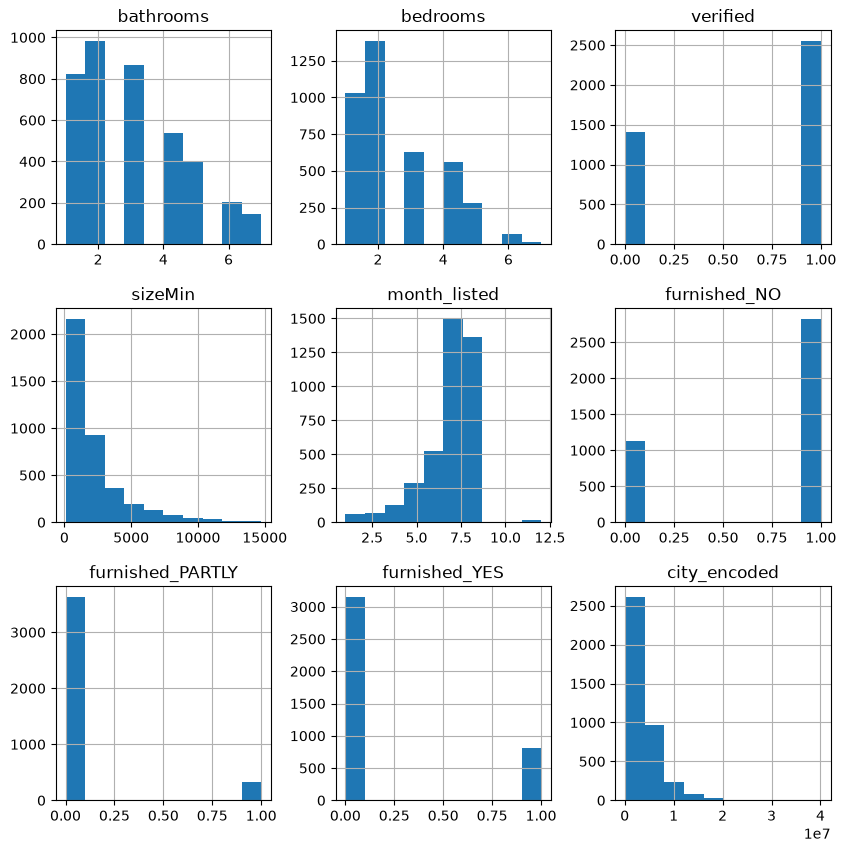

In [52]:
X_train.hist(figsize=(10, 10))

In [55]:
# Feature Scaling

# Scale only continuous numeric features (not binary columns)
cols_to_scale = ['bathrooms', 'bedrooms', 'sizeMin', 'month_listed', 'city_encoded']

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("\n=== Final Feature Summary ===")

print("\n=== Training Set ===")
print(X_train[cols_to_scale].describe().round(2))
print(X_train.shape, "\n")

print("\n=== Test Set ===")
print(X_test[cols_to_scale].describe().round(2))
print(X_test.shape)


=== Final Feature Summary ===

=== Training Set ===
       bathrooms  bedrooms  sizeMin  month_listed  city_encoded
count    3963.00   3963.00  3963.00       3963.00       3963.00
mean       -0.00      0.00     0.00          0.00         -0.00
std         1.00      1.00     1.00          1.00          1.00
min        -1.21     -1.11    -0.94         -4.22         -1.02
25%        -0.60     -1.11    -0.63         -0.61         -0.65
50%         0.02     -0.36    -0.37          0.12         -0.22
75%         0.63      0.39     0.21          0.84          0.17
max         2.46      3.40     5.53          3.73          9.54
(3963, 9) 


=== Test Set ===
       bathrooms  bedrooms  sizeMin  month_listed  city_encoded
count     991.00    991.00   991.00        991.00        991.00
mean        0.03      0.05    -0.00         -0.04         -0.01
std         1.03      1.00     1.01          1.03          1.05
min        -1.21     -1.11    -0.85         -4.22         -0.97
25%        -0.60     

array([[<Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'verified'}>],
       [<Axes: title={'center': 'sizeMin'}>,
        <Axes: title={'center': 'month_listed'}>,
        <Axes: title={'center': 'furnished_NO'}>],
       [<Axes: title={'center': 'furnished_PARTLY'}>,
        <Axes: title={'center': 'furnished_YES'}>,
        <Axes: title={'center': 'city_encoded'}>]], dtype=object)

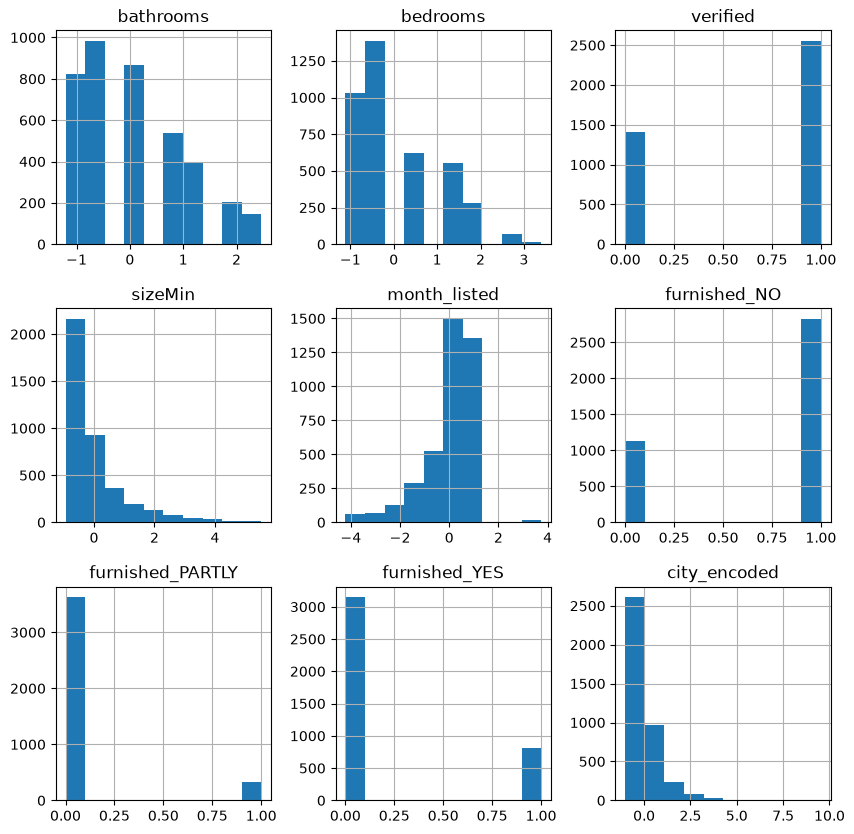

In [56]:
X_train.hist(figsize=(10, 10))

Data preprocessig is complete

# 1. Load Data and Initial Split

In [ ]:
# loading in the UAE real estate dataset
csv_filename = "uae_real_estate_cleaned.csv"
df = pd.read_csv(csv_filename)

# price is what we're trying to predict so we separate it from the rest
target_column = "price"
X = df.drop(columns=[target_column])  # everything except price = features
y = df[target_column]                 # just the price column = what we predict

# splitting into 80% for training/validation and 20% we lock away for final testing
# random_state=42 just means the split is always the same every time we run it
X_group1, X_group2, y_group1, y_group2 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Data loaded successfully!")
print(f"Group 1 (Train/Validation) Size: {X_group1.shape[0]} rows")
print(f"Group 2 (Final Test) Size: {X_group2.shape[0]} rows\n")


# 2. K-Fold Cross Validation (Baseline)

In [ ]:
# using 5-fold cross validation - basically splits group1 into 5 chunks
# trains on 4 chunks, tests on 1, repeats 5 times so every chunk gets tested once
# this gives a much more reliable score than just a single train/test split
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# these are the 3 models we're comparing - all using default settings for now (baseline)
# we tune them properly in the next section
models = {
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", Ridge())
    ]),

    "Random Forest": Pipeline([
        ("pca", PCA(n_components=0.95)),
        ("model", RandomForestRegressor(random_state=42))
    ]),

    "HistGradientBoosting": Pipeline([
        ("pca", PCA(n_components=0.95)),
        ("model", HistGradientBoostingRegressor(random_state=42))
    ])
}

print("--- Running K-Fold Cross Validation on Group 1 (Baseline) ---")

cv_results = {}
best_cv_score = float('-inf')
best_model_name = ""

for name, model in models.items():
    # r2 score tells us how well the model explains the variation in price
    # 1.0 = perfect, 0 = no better than just guessing the average price
    scores = cross_val_score(model, X_group1, y_group1, cv=kf, scoring='r2')
    mean_score = np.mean(scores)
    cv_results[name] = mean_score
    print(f"  {name} -> Average R2 Score: {mean_score:.4f}")

    # keeping track of which model did best so far
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_model_name = name

print(f"\n Best Baseline Model: {best_model_name} (R2={best_cv_score:.4f})\n")


# 3. Hyperparameter Tuning with GridSearchCV

In [ ]:
# ok so this is the main part - hyperparameter tuning
# basically we try out a bunch of different settings for each model
# GridSearchCV tests every possible combination and picks the best one
# n_jobs=-1 just means use all CPU cores so it runs faster

print("--- Hyperparameter Tuning ---\n")

# --- Ridge Regression ---
# alpha controls how much we penalize the model for being too complex
# too low = model overfits (memorizes training data), too high = underfits (too simple)
# so we try a wide range to find the sweet spot
ridge_param_grid = {
    'pca__n_components': [0.90, 0.95, 0.99],
    'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]
}

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_group1, y_group1)
print(f"Ridge Best Params : {ridge_grid.best_params_}  R2={ridge_grid.best_score_:.4f}")

# --- Random Forest ---
# n_estimators = how many trees to build (more = better but slower)
# max_depth = how deep each tree can go (too deep = overfitting)
# min_samples_split = minimum rows needed before splitting a node
# max_features = how many features each tree looks at when splitting
rf_param_grid = {
    'pca__n_components': [0.90, 0.95, 0.99],
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline([
    ("pca", PCA()),
    ("model", RandomForestRegressor(random_state=42))
])

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_group1, y_group1)
print(f"Random Forest Best Params : {rf_grid.best_params_}  R2={rf_grid.best_score_:.4f}")

# --- HistGradientBoosting ---
# this one builds trees one at a time where each tree fixes the mistakes of the last
# learning_rate = how much each tree contributes (lower = more careful but needs more trees)
# max_iter = total number of trees to build
# max_depth = depth of each individual tree
# l2_regularization = prevents overfitting similar to ridge's alpha
hgb_param_grid = {
    'pca__n_components': [0.90, 0.95, 0.99],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__max_iter': [100, 200, 300]
}

hgb_pipeline = Pipeline([
    ("pca", PCA()),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

hgb_grid = GridSearchCV(
    hgb_pipeline,
    hgb_param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

hgb_grid.fit(X_group1, y_group1)
print(f"HGB Best Params   : {hgb_grid.best_params_}  R2={hgb_grid.best_score_:.4f}")

# now we figure out which tuned model actually won
tuned_scores = {
    "Ridge Regression":     ridge_grid.best_score_,
    "Random Forest":        rf_grid.best_score_,
    "HistGradientBoosting": hgb_grid.best_score_,
}
best_tuned_name = max(tuned_scores, key=tuned_scores.get)
best_tuned_score = tuned_scores[best_tuned_name]

# storing the actual fitted models so we can use the winner in the next step
best_tuned_estimators = {
    "Ridge Regression":     ridge_grid.best_estimator_,
    "Random Forest":        rf_grid.best_estimator_,
    "HistGradientBoosting": hgb_grid.best_estimator_,
}

print(f"\n Best Tuned Model: {best_tuned_name} (R2={best_tuned_score:.4f})")
print(f" Improvement over baseline: {best_tuned_score - cv_results[best_tuned_name]:+.4f}\n")


# 4. Final Evaluation on Group 2 (Hold-Out Test Set)

In [ ]:
# this is the moment of truth - we finally use group 2 which we haven't touched at all
# first we retrain the winning tuned model on ALL of group 1 (not just 4/5 of it)
# then we predict on group 2 and see how it actually performs on completely unseen data
final_model = best_tuned_estimators[best_tuned_name]
final_model.fit(X_group1, y_group1)

final_predictions = final_model.predict(X_group2)

# R2 = how much of the price variation our model explains (higher = better)
# RMSE = average prediction error in the same units as price (lower = better)
true_r2   = r2_score(y_group2, final_predictions)
true_rmse = np.sqrt(mean_squared_error(y_group2, final_predictions))

print(f" Final Model Performance Report (Tuned):")
print(f"   - Selected Model : {best_tuned_name}")
print(f"   - True R2 Score  (Group 2): {true_r2:.4f}")
print(f"   - True RMSE      (Group 2): {true_rmse:.2f}\n")


# 5. Model Comparison: Baseline vs Tuned

In [ ]:
# making a comparison chart so we can actually see how much the tuning helped
# blue bars = baseline (default settings), green bars = after tuning
# the red dashed line shows the final real-world score on group 2
model_names = list(cv_results.keys())
baseline_scores = [cv_results[n] for n in model_names]
tuned_scores_list = [tuned_scores[n] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, tuned_scores_list, width, label='Tuned', color='seagreen', alpha=0.8)

ax.set_ylabel('Average R2 Score (CV)')
ax.set_title('Model Comparison - Baseline vs Hyperparameter Tuned')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1)

# this line shows how the best model actually did on the holdout test set
ax.axhline(y=true_r2, color='red', linestyle='--', label=f'Final Test R2={true_r2:.4f}')
ax.legend()

# adding the actual numbers on top of each bar so its easy to read
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


# 4. Model Comparison and Review


In [ ]:
# --- Plot 1: Actual vs Predicted Prices (Group 2) ---
# each dot = one property, x = real price, y = what our model guessed
# the red line = perfect predictions, dots close to it = good predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_group2, final_predictions, alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_group2.min(), y_group2.max()],
         [y_group2.min(), y_group2.max()],
         color='red', linewidth=1.5, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title('Actual vs Predicted Prices — Random Forest (Group 2)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 2: Residual Plot (Group 2) ---
# residual = predicted price minus actual price
# dots scattered randomly around 0 = good, any pattern = the model has a bias problem
residuals = final_predictions - y_group2

plt.figure(figsize=(8, 6))
plt.scatter(final_predictions, residuals, alpha=0.4, color='seagreen', edgecolors='none')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')

plt.xlabel('Predicted Price (AED)')
plt.ylabel('Residual (Predicted - Actual)')
plt.title('Residual Plot — Random Forest (Group 2)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 3: Feature Importance — Random Forest ---
# shows which features the model used most when deciding the predicted price
# higher bar = that feature had more influence on predictions
feature_names = X_group1.columns
if best_tuned_name == "Random Forest":

    rf_model = final_model.named_steps["model"]

    importances = rf_model.feature_importances_

    pca_features = [
        f"PC{i+1}"
        for i in range(len(importances))
    ]

    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.bar(
        np.array(pca_features)[sorted_idx],
        importances[sorted_idx]
    )

    plt.title("Random Forest Feature Importance (PCA Components)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# sorting features from most to least important so the chart is easy to read
"""sorted_indices = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_indices]
sorted_names = feature_names[sorted_indices]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_names)), sorted_importances, color='steelblue', alpha=0.8)
plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()"""


In [ ]:
# --- Plot 4: Cross-Validation Score Distribution (Box Plot) ---
# instead of just showing the average R2, this shows the spread across all 5 folds
# a short box sitting high = consistent and accurate, tall box = unstable performance
all_cv_scores = {}

for name, model in best_tuned_estimators.items():
    # re-running CV with the tuned version of each model to get the 5 individual fold scores
    scores = cross_val_score(model, X_group1, y_group1, cv=kf, scoring='r2')
    all_cv_scores[name] = scores

plt.figure(figsize=(8, 6))
plt.boxplot(all_cv_scores.values(), labels=all_cv_scores.keys(), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))

plt.ylabel('R2 Score (per fold)')
plt.title('Cross-Validation Score Distribution — Tuned Models')
plt.tight_layout()
plt.show()

In [ ]:
# --- Summary Table: All Models Baseline vs Tuned vs Final Test ---
# brings all the key numbers together in one place for easy comparison
# final test score only applies to the winning model (Random Forest)
print("=" * 62)
print(f"{'Model':<25} {'Baseline R2':>12} {'Tuned R2':>10} {'Test R2':>10}")
print("=" * 62)

for name in models.keys():
    baseline = cv_results[name]
    tuned    = tuned_scores[name]
    # only the best tuned model was evaluated on group 2, so show '-' for the others
    test     = f"{true_r2:.4f}" if name == best_tuned_name else "-"
    print(f"{name:<25} {baseline:>12.4f} {tuned:>10.4f} {test:>10}")

print("=" * 62)
print(f"\n Final selected model : {best_tuned_name}")
print(f" Group 2 R2           : {true_r2:.4f}")
print(f" Group 2 RMSE         : {true_rmse:.2f} AED")